# 3 A portfolio with a risky and a safe asset

In [1]:
# Imports 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### 3.1 Question 1

#### 3.1.1 Simulation of returns

Using the seed 2026, the shocks $\varepsilon_t$ were drawn from a standard normal distribution and the risky gross returns were computed as

$$
R_t=\exp(\mu+\sigma\varepsilon_t).
$$

#### 3.1.2 Moments of the return distribution
The simulated moments are:

- Mean of $\log(R_t)$: $0.0499$
- Theoretical value $\mu$: $0.0500$

- Standard deviation of $\log(R_t)$: $0.2000$
- Theoretical value $\sigma$: $0.2000$

- Mean of $R_t$: $1.0724$

The theoretical mean return is

$$
E[R_t]
=
\exp\left(\mu+\frac{1}{2}\sigma^2\right)
=
\exp(0.05+0.5\cdot0.20^2)
=
1.0725.
$$

The simulated values are extremely close to the theoretical values, indicating that the return process has been implemented correctly.

#### 3.1.3 Figure
Figure 1 shows:

- A histogram of the simulated risky returns $R_t$.
- The value of \$1 invested in the risky asset and in the safe asset for 20 selected portfolios.

The wealth paths are plotted on a logarithmic scale in the second panel.

Mean(log(R)): 0.049885205872910204
Theoretical mu: 0.05

Std(log(R)): 0.1999738329208296
Theoretical sigma: 0.2

Mean(R): 1.0723736438453322
Theoretical E(R): 1.0725081812542165


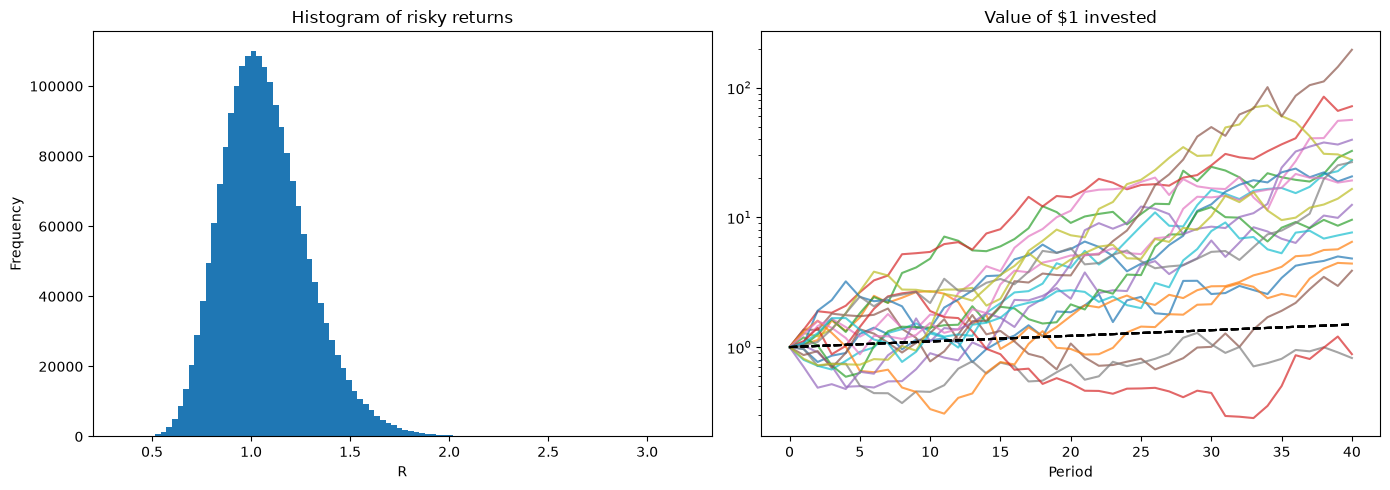

In [5]:
# 3.1.1 Imports and parameters

np.random.seed(2026)

mu = 0.05
sigma = 0.20
r = 0.01

theta_star = 0.50
Delta = 0.10
tau = 0.01
gamma = 3

W0 = 1
T = 40
N = 50_000


# 3.1.1 Draw epsilon and compute returns

eps = np.random.normal(size=(N, T))

R_risky = np.exp(mu + sigma * eps)
R_safe = np.exp(r)


# 3.1.2 Sample moments

mean_logR = np.log(R_risky).mean()
std_logR = np.log(R_risky).std()

mean_R = R_risky.mean()
theoretical_mean_R = np.exp(mu + 0.5 * sigma**2)

print("Mean(log(R)):", mean_logR)
print("Theoretical mu:", mu)

print("\nStd(log(R)):", std_logR)
print("Theoretical sigma:", sigma)

print("\nMean(R):", mean_R)
print("Theoretical E(R):", theoretical_mean_R)


# 3.1.3 Histogram of risky returns

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].hist(R_risky.flatten(), bins=100)
ax[0].set_title("Histogram of risky returns")
ax[0].set_xlabel("R")
ax[0].set_ylabel("Frequency")


# 3.1.3 Wealth paths for 20 portfolios

risky_path = np.ones((20, T + 1))
safe_path = np.ones((20, T + 1))

for t in range(T):

    risky_path[:, t + 1] = (
        risky_path[:, t] * R_risky[:20, t]
    )

    safe_path[:, t + 1] = (
        safe_path[:, t] * R_safe
    )

for i in range(20):

    ax[1].plot(risky_path[i], alpha=0.7)

for i in range(20):

    ax[1].plot(
        safe_path[i],
        linestyle="--",
        color="black",
        alpha=0.3
    )

ax[1].set_yscale("log")
ax[1].set_title("Value of $1 invested")
ax[1].set_xlabel("Period")

plt.tight_layout()
plt.show()

### 3.2 Question 2

#### 3.2.1 Portfolio simulator

The simulator was implemented by looping over the $T=40$ periods while vectorizing over the $N=50{,}000$ portfolios. Wealth $W_t$ and portfolio shares $\theta_t$ were stored for all periods.

#### 3.2.2 Extreme trading rules

With transaction costs set to $\tau=0$, the six requested statistics are:

##### $\Delta=0$ (trade every period)

- Average number of trades: $39.0$
- Average distance to target: $0.0394$
- Mean terminal wealth: $5.0282$
- Median terminal wealth: $4.0531$
- 10th percentile of terminal wealth: $1.7916$
- Expected utility: $-0.0674$

##### $\Delta=1$ (never trade)

- Average number of trades: $0.0$
- Average distance to target: $0.1912$
- Mean terminal wealth: $8.9480$
- Median terminal wealth: $4.4199$
- 10th percentile of terminal wealth: $1.4780$
- Expected utility: $-0.0769$

#### 3.2.3 Figure

Figure 2 shows:

- A histogram of terminal wealth $W_T$ for the two extreme rules.
- The mean risky portfolio share $\theta_t$ together with the 10th and 90th percentile bands.

#### 3.2.4 Description

When the portfolio is never traded ($\Delta=1$), the risky portfolio share evolves because the risky and safe assets earn different returns over time. The share gradually drifts away from the target value $\theta^*=0.5$, and the dispersion across portfolios increases. Some portfolios become heavily invested in the risky asset, while others end up with a much lower risky share.

When the portfolio is rebalanced every period ($\Delta=0$), the risky share is returned to the target whenever it has moved away from it, so it remains close to $\theta^*$ throughout the simulation.


         Avg trades  Avg distance  Mean WT  Median WT  P10 WT  \
Delta=0        39.0        0.0394   5.0282     4.0531  1.7916   
Delta=1         0.0        0.1912   8.9480     4.4199  1.4780   

         Expected utility  
Delta=0           -0.0674  
Delta=1           -0.0769  


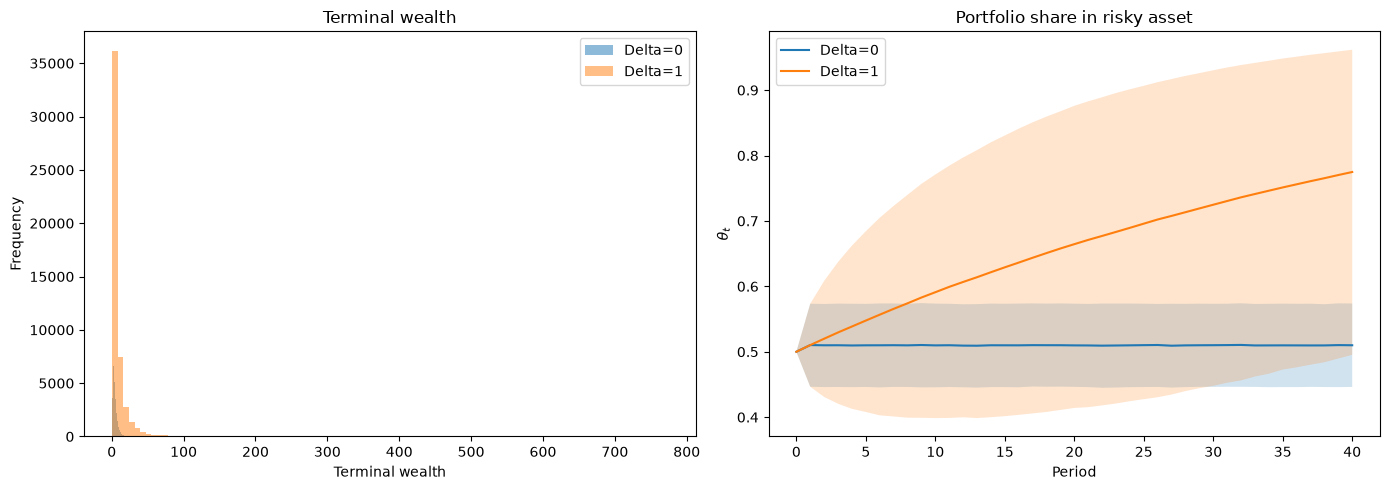

In [8]:
# 3.2.1 Portfolio simulator

def simulate_portfolios(delta, tau, returns):

    W = np.zeros((N, T + 1))
    theta = np.zeros((N, T + 1))

    W[:, 0] = W0
    theta[:, 0] = theta_star

    trade_count = np.zeros(N)
    total_distance = 0.0

    for t in range(T):

        theta_current = theta[:, t]

        distance = np.abs(theta_current - theta_star)
        total_distance += distance.sum()

        rebalance = distance > delta

        theta_post = np.where(
            rebalance,
            theta_star,
            theta_current
        )

        trade_count += rebalance.astype(int)

        W_post = W[:, t] * (
            1 - tau * np.abs(theta_post - theta_current)
        )

        W_next = (
            theta_post * W_post * returns[:, t]
            + (1 - theta_post) * W_post * R_safe
        )

        theta_next = (
            theta_post * W_post * returns[:, t]
        ) / W_next

        W[:, t + 1] = W_next
        theta[:, t + 1] = theta_next

    WT = W[:, -1]

    utility = WT**(1 - gamma) / (1 - gamma)

    stats = {
        "Avg trades": trade_count.mean(),
        "Avg distance": total_distance / (N * T),
        "Mean WT": WT.mean(),
        "Median WT": np.median(WT),
        "P10 WT": np.percentile(WT, 10),
        "Expected utility": utility.mean()
    }

    return stats, W, theta


# 3.2.2 Simulate Delta=0 and Delta=1 with tau=0
stats_trade, W_trade, theta_trade = simulate_portfolios(
    delta=0,
    tau=0,
    returns=R_risky
)

stats_never, W_never, theta_never = simulate_portfolios(
    delta=1,
    tau=0,
    returns=R_risky
)

comparison = pd.DataFrame(
    [stats_trade, stats_never],
    index=["Delta=0", "Delta=1"]
)

print(comparison.round(4))


# 3.2.3 Figure: histogram of terminal wealth
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].hist(
    W_trade[:, -1],
    bins=100,
    alpha=0.5,
    label="Delta=0"
)
ax[0].hist(
    W_never[:, -1],
    bins=100,
    alpha=0.5,
    label="Delta=1"
)
ax[0].set_title("Terminal wealth")
ax[0].set_xlabel("Terminal wealth")
ax[0].set_ylabel("Frequency")
ax[0].legend()


# 3.2.3 Figure: mean theta and percentile bands
time = np.arange(T + 1)

for theta_data, label in [
    (theta_trade, "Delta=0"),
    (theta_never, "Delta=1")
]:

    mean_theta = theta_data.mean(axis=0)
    p10 = np.percentile(theta_data, 10, axis=0)
    p90 = np.percentile(theta_data, 90, axis=0)

    ax[1].plot(time, mean_theta, label=label)
    ax[1].fill_between(time, p10, p90, alpha=0.2)

ax[1].set_title("Portfolio share in risky asset")
ax[1].set_xlabel("Period")
ax[1].set_ylabel(r"$\theta_t$")
ax[1].legend()

plt.tight_layout()
plt.show()


### 3.3 Question 3

#### 3.3.1 Results for different no-trade bands

The six requested statistics are reported below.

| $\Delta$ | Avg. trades | Avg. distance | Mean $W_T$ | Median $W_T$ | 10th pct. $W_T$ | Expected utility |
|----------:|------------:|--------------:|-----------:|-------------:|-----------------:|------------------:|
| 0.000 | 39.0000 | 0.0394 | 4.9473 | 3.9883 | 1.7646 | -0.0695 |
| 0.025 | 24.5288 | 0.0400 | 4.9595 | 3.9966 | 1.7659 | -0.0693 |
| 0.050 | 14.3407 | 0.0430 | 5.0014 | 4.0108 | 1.7680 | -0.0689 |
| 0.075 | 8.8154 | 0.0480 | 5.0597 | 4.0247 | 1.7614 | -0.0689 |
| 0.100 | 5.8882 | 0.0541 | 5.1335 | 4.0431 | 1.7550 | -0.0690 |
| 0.150 | 3.1491 | 0.0680 | 5.3157 | 4.0792 | 1.7300 | -0.0695 |
| 0.200 | 1.9542 | 0.0835 | 5.5469 | 4.1696 | 1.6894 | -0.0704 |
| 0.300 | 0.9031 | 0.1182 | 6.1737 | 4.3242 | 1.5362 | -0.0731 |
| 1.000 | 0.0000 | 0.1912 | 8.9480 | 4.4199 | 1.4780 | -0.0769 |

#### 3.3.2 Figure

The first panel shows average trades and average distance to the target portfolio share as functions of $\Delta$, using separate y-axes so both series are visible. The second panel shows expected utility as a function of $\Delta$.

#### 3.3.3 Optimal no-trade band

The highest expected utility is obtained at

$$
\Delta^*=0.075.
$$

The corresponding expected utility is

$$
E[u(W_T)] = -0.068889.
$$

Compared with $\Delta=0$, the improvement is

$$
-0.068889 - (-0.069471) = 0.000582.
$$

Compared with $\Delta=1$, the improvement is

$$
-0.068889 - (-0.076891) = 0.008002.
$$

#### 3.3.4 Description

As $\Delta$ increases, portfolios are rebalanced less frequently. Consequently, the average number of trades falls, while the average distance to the target allocation increases.

Expected utility initially improves because fewer trades reduce transaction costs. When $\Delta$ becomes too large, the portfolio drifts further away from the target allocation and expected utility declines.

From $\Delta=0$ to the optimal value $\Delta=0.075$, the average number of trades changes substantially, decreasing from $39.0$ to $8.82$. The average distance to the target also increases. In contrast, mean terminal wealth, median terminal wealth, the 10th percentile of terminal wealth, and expected utility change relatively little.

Ranking the rules by mean terminal wealth would lead to a different choice. The highest mean terminal wealth is obtained at $\Delta=1$, whereas expected utility is highest at $\Delta=0.075$. Therefore, the preferred rule depends on the investor's risk preferences.


   Delta  Avg trades  Avg distance  Mean WT  Median WT  P10 WT  \
0  0.000     39.0000        0.0394   4.9473     3.9883  1.7646   
1  0.025     24.5288        0.0400   4.9595     3.9966  1.7659   
2  0.050     14.3407        0.0430   5.0014     4.0108  1.7680   
3  0.075      8.8154        0.0480   5.0597     4.0247  1.7614   
4  0.100      5.8882        0.0541   5.1335     4.0431  1.7550   
5  0.150      3.1491        0.0680   5.3157     4.0792  1.7300   
6  0.200      1.9542        0.0835   5.5469     4.1696  1.6894   
7  0.300      0.9031        0.1182   6.1737     4.3242  1.5362   
8  1.000      0.0000        0.1912   8.9480     4.4199  1.4780   

   Expected utility  
0           -0.0695  
1           -0.0693  
2           -0.0689  
3           -0.0689  
4           -0.0690  
5           -0.0695  
6           -0.0704  
7           -0.0731  
8           -0.0769  


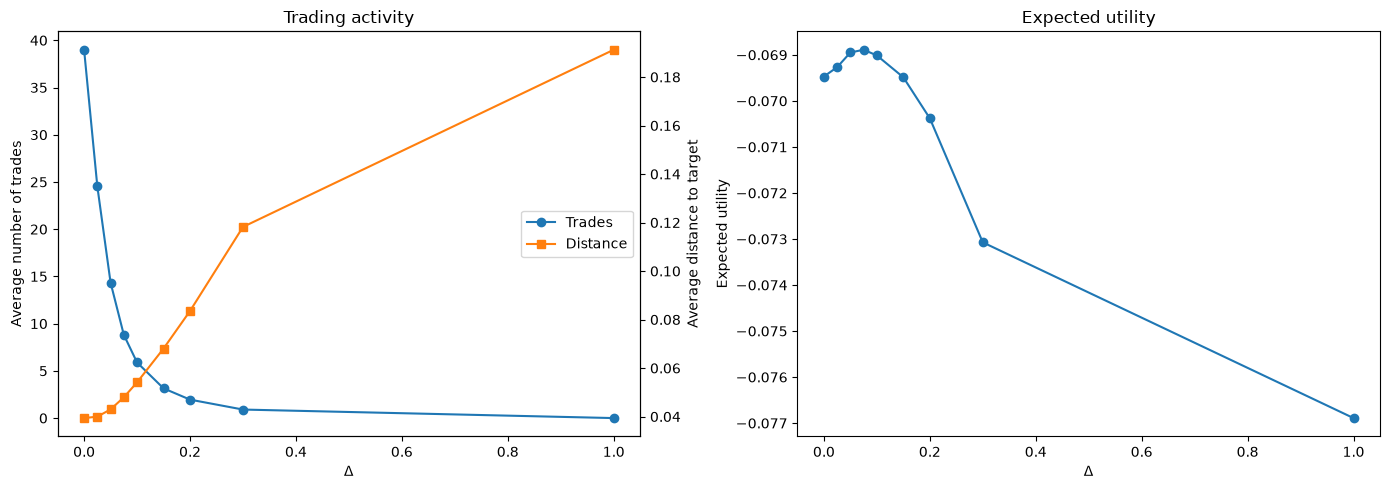

Best Delta: 0.075
Expected Utility: -0.068889
Improvement relative to Delta=0: 0.000582
Improvement relative to Delta=1: 0.008002


In [9]:
# 3.3.1 Band widths

deltas = [
    0,
    0.025,
    0.05,
    0.075,
    0.10,
    0.15,
    0.20,
    0.30,
    1.0
]

tau = 0.01


# 3.3.1 Simulate all rules
results = []

for delta in deltas:

    stats, _, _ = simulate_portfolios(
        delta=delta,
        tau=tau,
        returns=R_risky
    )

    stats["Delta"] = delta
    results.append(stats)

results_df = pd.DataFrame(results)
results_df = results_df[
    [
        "Delta",
        "Avg trades",
        "Avg distance",
        "Mean WT",
        "Median WT",
        "P10 WT",
        "Expected utility"
    ]
]

print(results_df.round(4))


# 3.3.2 Plot trading measures and utility
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

trades_line = ax[0].plot(
    results_df["Delta"],
    results_df["Avg trades"],
    marker="o",
    label="Trades"
)
ax[0].set_xlabel(r"$\Delta$")
ax[0].set_ylabel("Average number of trades")
ax[0].set_title("Trading activity")

ax_distance = ax[0].twinx()
distance_line = ax_distance.plot(
    results_df["Delta"],
    results_df["Avg distance"],
    marker="s",
    color="tab:orange",
    label="Distance"
)
ax_distance.set_ylabel("Average distance to target")

lines = trades_line + distance_line
labels = [line.get_label() for line in lines]
ax[0].legend(lines, labels, loc="center right")

ax[1].plot(
    results_df["Delta"],
    results_df["Expected utility"],
    marker="o"
)
ax[1].set_xlabel(r"$\Delta$")
ax[1].set_ylabel("Expected utility")
ax[1].set_title("Expected utility")

plt.tight_layout()
plt.show()


# 3.3.3 Best band width
best_idx = results_df["Expected utility"].idxmax()

best_delta = results_df.loc[best_idx, "Delta"]
best_utility = results_df.loc[best_idx, "Expected utility"]

utility_delta0 = results_df.loc[
    results_df["Delta"] == 0,
    "Expected utility"
].iloc[0]

utility_delta1 = results_df.loc[
    results_df["Delta"] == 1,
    "Expected utility"
].iloc[0]

print(f"Best Delta: {best_delta:.3f}")
print(f"Expected Utility: {best_utility:.6f}")
print(
    f"Improvement relative to Delta=0: "
    f"{best_utility - utility_delta0:.6f}"
)
print(
    f"Improvement relative to Delta=1: "
    f"{best_utility - utility_delta1:.6f}"
)
